## Notebook purpose (conceptual overview)

This notebook analyzes **vector consistency across participants** and builds a simple **cheater/fraud detector**.

Conceptually:

- A participant produces vectors for many nonces.
- Other participants request a random subset of those nonces and recompute vectors locally.
- For each requested nonce, the verifier compares the received vector to its locally reconstructed vector.
- If the L2 distance exceeds a threshold, that nonce is a **mismatch**.

We calibrate the mismatch threshold from an **honest distance distribution** (98th percentile → ~2% expected mismatches), then use a **one-sided binomial test** to flag pairs/participants with significantly higher mismatch rates.

The final section runs **simulations** to show expected p-values under honest/cheater mismatch rates.

In [205]:
import json
import itertools
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt



## Configure which runs to compare

You list the run directories to analyze.

Conceptually: each directory is a different participant/server run, producing a matrix of vectors over the same set of nonces. We’ll compare them pairwise to detect outliers.

In [206]:
# Configuration - update paths to the runs you want to compare
RUN_DIRS = [
    Path("/root/vllm/scripts/notebooks/data/A100_235B_int4_flashinfer"),
    Path("/root/vllm/scripts/notebooks/data/A100_235B_fp8_flashinfer"),
    Path("/root/vllm/scripts/notebooks/data/H100_235B_fp8"),
    Path("/root/vllm/scripts/notebooks/data/H100_235B_int4"),
    Path("/root/vllm/scripts/notebooks/data/B200_235B_fp8"),
]

# Labels used throughout the notebook (defaults to directory name)
RUN_LABELS = {p: p.name for p in RUN_DIRS}


## Load runs (configs + vector logs)

Each “run directory” represents one participant/server configuration (e.g., GPU type, dtype, quantization).

This cell:

- Loads `config.json` (metadata)
- Loads the single `*.json` data file containing recorded vectors (and optional nonces)
- Builds a common `data[...]` structure and a `servers` list used by the rest of the notebook

In [207]:
# Load config + vectors for each run directory
configs = {}
data = {}

for run_dir in RUN_DIRS:
    label = RUN_LABELS.get(run_dir, run_dir.name)

    with open(run_dir / "config.json") as f:
        cfg = json.load(f)
    configs[label] = cfg

    # New structure: one data file per config/run (e.g. local_mlnode.json)
    json_files = [p for p in run_dir.glob("*.json") if p.name != "config.json"]
    if len(json_files) != 1:
        raise RuntimeError(
            f"{run_dir}: expected exactly 1 data json besides config.json, got {json_files}"
        )
    vec_path = json_files[0]

    with open(vec_path) as fp:
        d = json.load(fp)

    data[label] = {
        "vectors": np.array(d["vectors"]),
        "nonces": d.get("nonces", []),
        "server_name": d.get("server_name", vec_path.stem),
        "run_dir": str(run_dir),
    }

print("Runs:")
for label in data:
    cfg = configs[label]
    print(f"\n- {label}")
    for k in [
        "model",
        "dtype",
        "enable_poc",
        "seq_len",
        "k_dim",
        "batch_size",
        "nonce_count",
    ]:
        if k in cfg:
            print(f"  {k}: {cfg[k]}")
    print(f"  data_file: {data[label]['server_name']}")
    print(f"  vectors: {data[label]['vectors'].shape}")

# Keep the same interface used by the rest of the notebook
servers = list(data.keys())
print(f"\nLoaded: {servers}")


Runs:

- A100_235B_int4_flashinfer
  model: chriswritescode/Qwen3-235B-A22B-Instruct-2507-INT4-W4A16
  dtype: bfloat16
  enable_poc: True
  seq_len: 1024
  k_dim: 12
  batch_size: 8
  nonce_count: 2000
  data_file: local_mlnode
  vectors: (2000, 12)

- A100_235B_fp8_flashinfer
  model: Qwen/Qwen3-235B-A22B-Instruct-2507-FP8
  dtype: bfloat16
  enable_poc: True
  seq_len: 1024
  k_dim: 12
  batch_size: 8
  nonce_count: 2000
  data_file: local_mlnode
  vectors: (2000, 12)

- H100_235B_fp8
  model: Qwen/Qwen3-235B-A22B-Instruct-2507-FP8
  dtype: bfloat16
  enable_poc: True
  seq_len: 1024
  k_dim: 12
  batch_size: 8
  nonce_count: 2000
  data_file: local_mlnode
  vectors: (2000, 12)

- H100_235B_int4
  model: chriswritescode/Qwen3-235B-A22B-Instruct-2507-INT4-W4A16
  dtype: bfloat16
  enable_poc: True
  seq_len: 1024
  k_dim: 12
  batch_size: 8
  nonce_count: 2000
  data_file: local_mlnode
  vectors: (2000, 12)

- B200_235B_fp8
  model: Qwen/Qwen3-235B-A22B-Instruct-2507-FP8
  dtype: bflo

## Compute per-nonce distances between every pair of runs

For each pair of runs (servers/configurations), we compare vectors **nonce-by-nonce** (same index) and compute the L2 distance.

- Output: `pairwise_dists[(runA, runB)]` is an array of distances, one per nonce.
- Interpretation: small distances mean both runs reconstructed the vector similarly; large distances mean disagreement (potential cheating or numerical mismatch).

In [208]:
# Compute pairwise L2 distances for same nonces across servers
pairwise_dists = {}

for s1, s2 in itertools.combinations(servers, 2):
    v1, v2 = data[s1]["vectors"], data[s2]["vectors"]
    dists = np.linalg.norm(v1 - v2, axis=1)
    pairwise_dists[(s1, s2)] = dists

# Pretty print
print("Pairwise L2 distances (same nonce, different servers):\n")
for (s1, s2), dists in pairwise_dists.items():
    n1, n2 = s1.replace("server_", ""), s2.replace("server_", "")
    print(f"  {n1:>8} vs {n2:<8}  {np.mean(dists):.6f} ± {np.std(dists):.6f}  (max {np.max(dists):.4f})")


Pairwise L2 distances (same nonce, different servers):

  A100_235B_int4_flashinfer vs A100_235B_fp8_flashinfer  0.241144 ± 0.100893  (max 1.0961)
  A100_235B_int4_flashinfer vs H100_235B_fp8  0.243977 ± 0.104461  (max 1.4753)
  A100_235B_int4_flashinfer vs H100_235B_int4  0.059914 ± 0.035187  (max 0.2957)
  A100_235B_int4_flashinfer vs B200_235B_fp8  0.244649 ± 0.102523  (max 1.3202)
  A100_235B_fp8_flashinfer vs H100_235B_fp8  0.070354 ± 0.040487  (max 0.5167)
  A100_235B_fp8_flashinfer vs H100_235B_int4  0.241756 ± 0.100651  (max 0.8875)
  A100_235B_fp8_flashinfer vs B200_235B_fp8  0.070842 ± 0.037405  (max 0.3272)
  H100_235B_fp8 vs H100_235B_int4  0.244396 ± 0.103905  (max 1.2914)
  H100_235B_fp8 vs B200_235B_fp8  0.077150 ± 0.040208  (max 0.4224)
  H100_235B_int4 vs B200_235B_fp8  0.245051 ± 0.101769  (max 1.1198)


## Heuristic: identify cheater-like runs via a “largest gap” split

We first compute the **mean** distance for every run-pair.

If there is one cheater (or one incompatible configuration), we often see two clusters:

- Low mean distances (runs that agree → “honest cluster”)
- High mean distances (pairs involving the outlier → “cheater cluster”)

This cell finds the **largest gap** in the sorted list of pairwise mean distances and uses it as a threshold to split pairs into `low_dist_pairs` (honest) and `high_dist_pairs` (cheater). It then counts which run appears most often among the high-distance pairs.

In [209]:
# Identify cheater: find server that appears in all high-distance pairs
# Auto-detect threshold by finding largest gap in sorted means
pair_means = sorted([(k, np.mean(v)) for k, v in pairwise_dists.items()], key=lambda x: x[1])
gaps = [(pair_means[i+1][1] - pair_means[i][1], i) for i in range(len(pair_means)-1)]
max_gap, gap_idx = max(gaps)
threshold = (pair_means[gap_idx][1] + pair_means[gap_idx+1][1]) / 2

print(f"Auto-detected threshold: {threshold:.6f} (gap: {max_gap:.6f})\n")

high_dist_pairs = [(s1, s2) for (s1, s2), d in pairwise_dists.items() if np.mean(d) > threshold]
low_dist_pairs = [(s1, s2) for (s1, s2), d in pairwise_dists.items() if np.mean(d) <= threshold]

# Count how many high-distance pairs each server appears in
suspect_count = {s: 0 for s in servers}
for s1, s2 in high_dist_pairs:
    suspect_count[s1] += 1
    suspect_count[s2] += 1

print(f"High-distance pairs: {len(high_dist_pairs)}")
print(f"Low-distance pairs:  {len(low_dist_pairs)}\n")

print("Server involvement in high-distance pairs:\n")
for s in sorted(servers, key=lambda x: suspect_count[x], reverse=True):
    name = s.replace("server_", "")
    count = suspect_count[s]
    total = len(high_dist_pairs)
    marker = " ← CHEATER" if count == total and total > 0 else ""
    print(f"  {name:>8}  {count}/{total}{marker}")


Auto-detected threshold: 0.159147 (gap: 0.163993)

High-distance pairs: 6
Low-distance pairs:  4

Server involvement in high-distance pairs:

  A100_235B_int4_flashinfer  3/6
  H100_235B_int4  3/6
  A100_235B_fp8_flashinfer  2/6
  H100_235B_fp8  2/6
  B200_235B_fp8  2/6


## Visualize separation between honest and cheater pairs

Using the earlier split into “honest” vs “cheater” *pairs of runs*, we plot their distance histograms.

Goal: give an intuitive picture of whether the cheater distances are well-separated from the honest distances (and by how much).

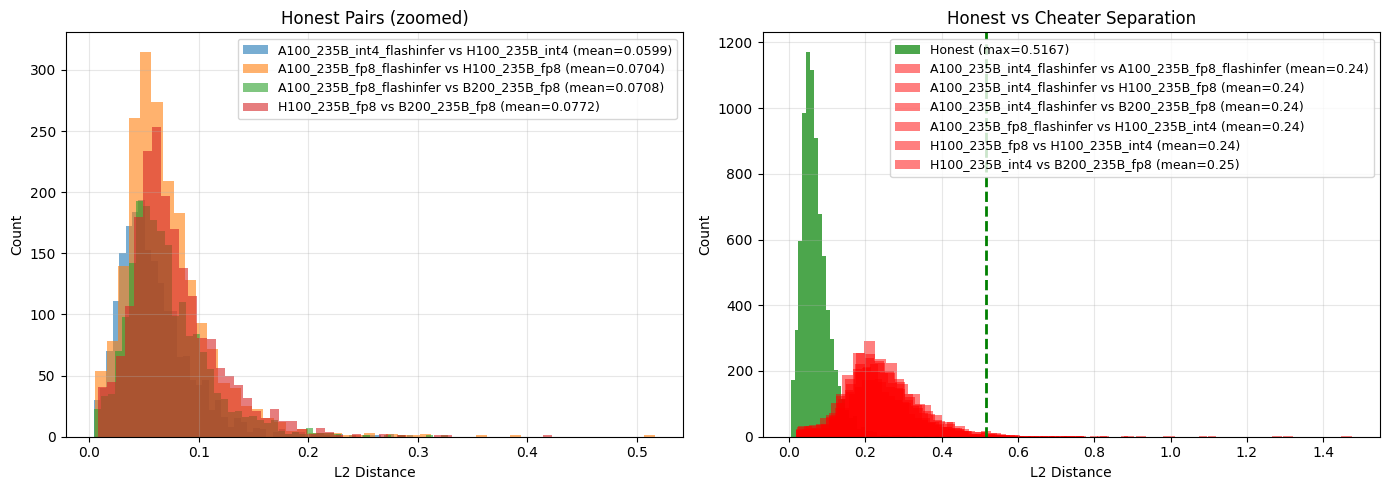


Separation: honest_max=0.5167, cheater_min=0.0168


In [210]:
# Visualization - split honest vs cheater for readability
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Use threshold from cell 5 (already computed)
honest = {k: v for k, v in pairwise_dists.items() if np.mean(v) < threshold}
cheater = {k: v for k, v in pairwise_dists.items() if np.mean(v) >= threshold}

# Left: Honest pairs (zoomed)
ax1 = axes[0]
for (s1, s2), dists in honest.items():
    label = f"{s1.replace('server_','')} vs {s2.replace('server_','')} (mean={np.mean(dists):.4f})"
    ax1.hist(dists, bins=50, alpha=0.6, label=label)
ax1.set_xlabel("L2 Distance")
ax1.set_ylabel("Count")
ax1.set_title("Honest Pairs (zoomed)")
ax1.legend(fontsize=9)
ax1.grid(True, alpha=0.3)

# Right: All pairs showing separation
ax2 = axes[1]
# Plot honest as one combined distribution
all_honest = np.concatenate(list(honest.values()))
ax2.hist(all_honest, bins=50, alpha=0.7, label=f"Honest (max={np.max(all_honest):.4f})", color="green")
# Plot cheater pairs
for (s1, s2), dists in cheater.items():
    label = f"{s1.replace('server_','')} vs {s2.replace('server_','')} (mean={np.mean(dists):.2f})"
    ax2.hist(dists, bins=50, alpha=0.5, label=label, color="red")
ax2.set_xlabel("L2 Distance")
ax2.set_ylabel("Count")
ax2.set_title("Honest vs Cheater Separation")
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3)
ax2.axvline(np.max(all_honest), color="green", linestyle="--", linewidth=2, label="honest max")

plt.tight_layout()
plt.show()

# Print separation margin
print(f"\nSeparation: honest_max={np.max(all_honest):.4f}, cheater_min={min(np.min(v) for v in cheater.values()):.4f}")


## Build the honest distance distribution and choose a threshold

We estimate what “normal” looks like by pooling distances from pairs deemed **honest**.

Then we choose a decision threshold:

- `dist_threshold` = the **98th percentile** of the honest distance distribution
- This implies an expected honest mismatch rate of roughly **2%** (false positives)

We compute and print the empirical `fp_rate` to confirm that calibration.

In [211]:
from scipy.stats import binomtest

# Statistical fraud detection based on honest pair distribution

# 1. Estimate honest distribution from all honest pairs
all_honest_dists = np.concatenate([pairwise_dists[k] for k in low_dist_pairs])
print(f"Honest distribution (n={len(all_honest_dists)}):")
print(f"  mean:   {np.mean(all_honest_dists):.6f}")
print(f"  std:    {np.std(all_honest_dists):.6f}")
print(f"  median: {np.median(all_honest_dists):.6f}")
print(f"  max:    {np.max(all_honest_dists):.6f}")

# 2. Set threshold at percentile of honest distribution
percentile = 98
dist_threshold = np.percentile(all_honest_dists, percentile)
print(f"\nThreshold at {percentile}th percentile: {dist_threshold:.6f}")

# 3. Estimate false positive rate from honest pairs
fp_count = np.sum(all_honest_dists > dist_threshold)
fp_rate = fp_count / len(all_honest_dists)
print(f"False positive rate on honest: {fp_count}/{len(all_honest_dists)} = {fp_rate:.6f}")


Honest distribution (n=8000):
  mean:   0.069565
  std:    0.038878
  median: 0.061853
  max:    0.516703

Threshold at 98th percentile: 0.173663
False positive rate on honest: 160/8000 = 0.020000


## Classifier-style summary (optional sanity check)

This cell treats the threshold rule as a binary classifier:

- **Score**: the per-nonce L2 distance
- **Predict cheater** if `distance > dist_threshold`

Using the earlier “honest vs cheater pair” split as a proxy ground truth, we compute a confusion matrix and derived rates (FPR/FNR). This is mainly a diagnostic to see how separable the distributions are.

In [212]:
# Classifier analysis using the honest 98th-percentile threshold
# Positive class = "cheater" (distance exceeds threshold)

# Ground truth: pairs with low mean distance are treated as honest; high mean distance as cheater
all_honest_dists = np.concatenate([pairwise_dists[k] for k in low_dist_pairs])
all_cheater_dists = np.concatenate([pairwise_dists[k] for k in high_dist_pairs])

scores = np.concatenate([all_honest_dists, all_cheater_dists])
y_true = np.concatenate([
    np.zeros(len(all_honest_dists), dtype=int),
    np.ones(len(all_cheater_dists), dtype=int),
])

# Prediction rule: flag as cheater if distance is above the honest 98th percentile
y_pred = (scores > dist_threshold).astype(int)

TP = int(np.sum((y_true == 1) & (y_pred == 1)))
TN = int(np.sum((y_true == 0) & (y_pred == 0)))
FP = int(np.sum((y_true == 0) & (y_pred == 1)))
FN = int(np.sum((y_true == 1) & (y_pred == 0)))

total = int(len(y_true))
accuracy = (TP + TN) / total if total else float("nan")

fpr = FP / (FP + TN) if (FP + TN) else float("nan")
fnr = FN / (FN + TP) if (FN + TP) else float("nan")

print(f"Classifier @ honest {percentile}th percentile threshold (dist_threshold={dist_threshold:.6f})")
print(f"N honest:  {len(all_honest_dists)}")
print(f"N cheater: {len(all_cheater_dists)}")
print()
print("Confusion matrix (positive=cheater):")
print(f"  TP: {TP}")
print(f"  FP: {FP}")
print(f"  TN: {TN}")
print(f"  FN: {FN}")
print()
print(f"Accuracy: {accuracy:.6f}")
print(f"FPR:      {fpr:.6f}   (FP/(FP+TN))")
print(f"FNR:      {fnr:.6f}   (FN/(FN+TP))")


Classifier @ honest 98th percentile threshold (dist_threshold=0.173663)
N honest:  8000
N cheater: 12000

Confusion matrix (positive=cheater):
  TP: 9264
  FP: 160
  TN: 7840
  FN: 2736

Accuracy: 0.855200
FPR:      0.020000   (FP/(FP+TN))
FNR:      0.228000   (FN/(FN+TP))


## Fraud detection as a binomial hypothesis test (per pair)

For each pair of runs (A vs B), we turn the distance checks into a mismatch count:

- For every nonce/vector, mark a **mismatch** if the distance exceeds `dist_threshold`.
- Under an honest pair, the mismatch probability should be close to `fp_rate` (~2%).

We then run a **one-sided** binomial test (alternative = "greater") to detect pairs whose mismatch rate is significantly **higher** than expected under honest behavior.

In [213]:
# 4. Test all pairs using binomial test
# H0: pair is honest (mismatch rate = fp_rate)
# H1: pair has higher mismatch rate (fraud)

fraud_threshold = 0.1  # p-value below this = fraud detected

print(f"Fraud detection (dist_threshold={dist_threshold:.6f}, expected_fp_rate={fp_rate:.6f}):\n")

for (s1, s2), dists in pairwise_dists.items():
    n_total = len(dists)
    n_exceed = np.sum(dists > dist_threshold)
    exceed_rate = n_exceed / n_total
    
    # Binomial test: is exceed rate significantly higher than expected?
    if fp_rate > 0:
        p_value = binomtest(n_exceed, n_total, fp_rate, alternative='greater').pvalue
    else:
        # If fp_rate=0, any exceed is suspicious
        p_value = 0.0 if n_exceed > 0 else 1.0
    
    fraud = p_value < fraud_threshold
    
    n1, n2 = s1.replace("server_", ""), s2.replace("server_", "")
    status = "FRAUD" if fraud else "OK"
    print(f"  {n1:>8} vs {n2:<8}  exceed: {n_exceed:3d}/{n_total} ({exceed_rate*100:5.1f}%)  p={p_value:.2e}  [{status}]")


Fraud detection (dist_threshold=0.173663, expected_fp_rate=0.020000):

  A100_235B_int4_flashinfer vs A100_235B_fp8_flashinfer  exceed: 1538/2000 ( 76.9%)  p=0.00e+00  [FRAUD]
  A100_235B_int4_flashinfer vs H100_235B_fp8  exceed: 1540/2000 ( 77.0%)  p=0.00e+00  [FRAUD]
  A100_235B_int4_flashinfer vs H100_235B_int4  exceed:  30/2000 (  1.5%)  p=9.58e-01  [OK]
  A100_235B_int4_flashinfer vs B200_235B_fp8  exceed: 1561/2000 ( 78.0%)  p=0.00e+00  [FRAUD]
  A100_235B_fp8_flashinfer vs H100_235B_fp8  exceed:  42/2000 (  2.1%)  p=3.96e-01  [OK]
  A100_235B_fp8_flashinfer vs H100_235B_int4  exceed: 1536/2000 ( 76.8%)  p=0.00e+00  [FRAUD]
  A100_235B_fp8_flashinfer vs B200_235B_fp8  exceed:  35/2000 (  1.8%)  p=8.09e-01  [OK]
  H100_235B_fp8 vs H100_235B_int4  exceed: 1533/2000 ( 76.6%)  p=0.00e+00  [FRAUD]
  H100_235B_fp8 vs B200_235B_fp8  exceed:  53/2000 (  2.6%)  p=2.68e-02  [FRAUD]
  H100_235B_int4 vs B200_235B_fp8  exceed: 1556/2000 ( 77.8%)  p=0.00e+00  [FRAUD]


## Visualize the honest threshold on distributions

We plot the empirical distance distributions:

- **Honest** distances (from pairs classified as honest earlier)
- **Cheater** distances (from high-distance pairs)

Then we draw the **98th-percentile honest threshold** as a vertical line. This visually explains why the threshold corresponds to ~2% false positives under the honest distribution.

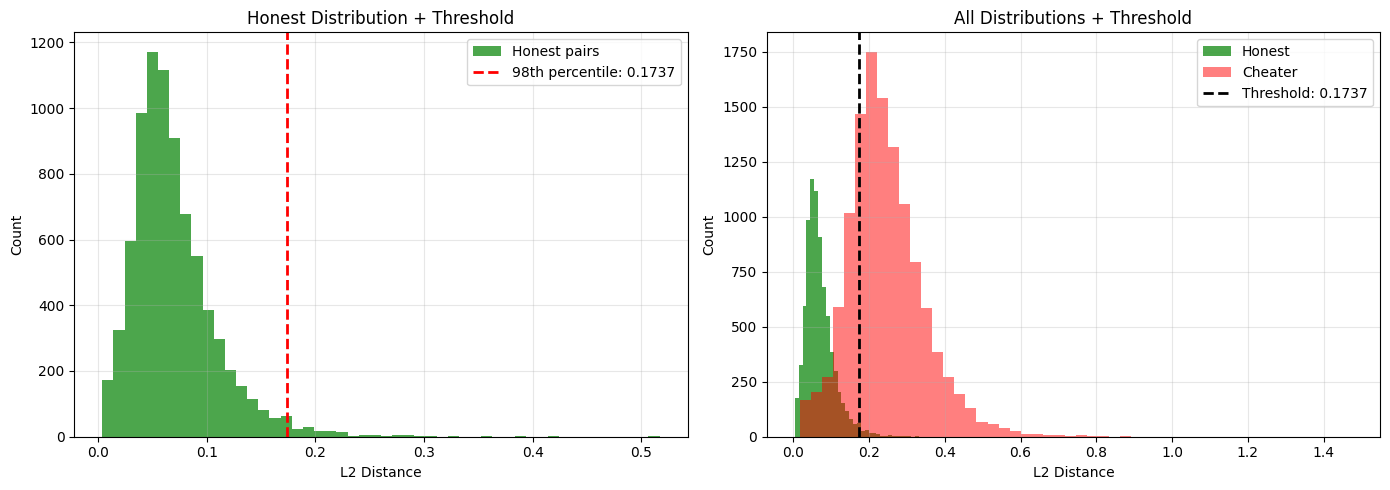


Cheater nonces exceeding threshold: 9264/12000 (77.2%)


In [214]:
# 5. Visualize threshold on distributions
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: Honest distribution with threshold
ax1 = axes[0]
ax1.hist(all_honest_dists, bins=50, alpha=0.7, color="green", label="Honest pairs")
ax1.axvline(dist_threshold, color="red", linestyle="--", linewidth=2, label=f"{percentile}th percentile: {dist_threshold:.4f}")
ax1.set_xlabel("L2 Distance")
ax1.set_ylabel("Count")
ax1.set_title("Honest Distribution + Threshold")
ax1.legend()
ax1.grid(True, alpha=0.3)

# Right: All pairs with threshold
ax2 = axes[1]
ax2.hist(all_honest_dists, bins=50, alpha=0.7, color="green", label="Honest")
all_cheater_dists = np.concatenate([pairwise_dists[k] for k in high_dist_pairs])
ax2.hist(all_cheater_dists, bins=50, alpha=0.5, color="red", label="Cheater")
ax2.axvline(dist_threshold, color="black", linestyle="--", linewidth=2, label=f"Threshold: {dist_threshold:.4f}")
ax2.set_xlabel("L2 Distance")
ax2.set_ylabel("Count")
ax2.set_title("All Distributions + Threshold")
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Summary stats
cheater_exceed = np.sum(all_cheater_dists > dist_threshold)
print(f"\nCheater nonces exceeding threshold: {cheater_exceed}/{len(all_cheater_dists)} ({cheater_exceed/len(all_cheater_dists)*100:.1f}%)")


## Heatmap summary of pairwise distances

This cell summarizes all pairwise comparisons in one view:

- Each run is a row/column.
- Each cell shows the **mean** L2 distance (and **std**) between vectors from those two runs.

This is a quick diagnostic to spot clusters (similar runs) and outliers (potential cheater / incompatible configuration).

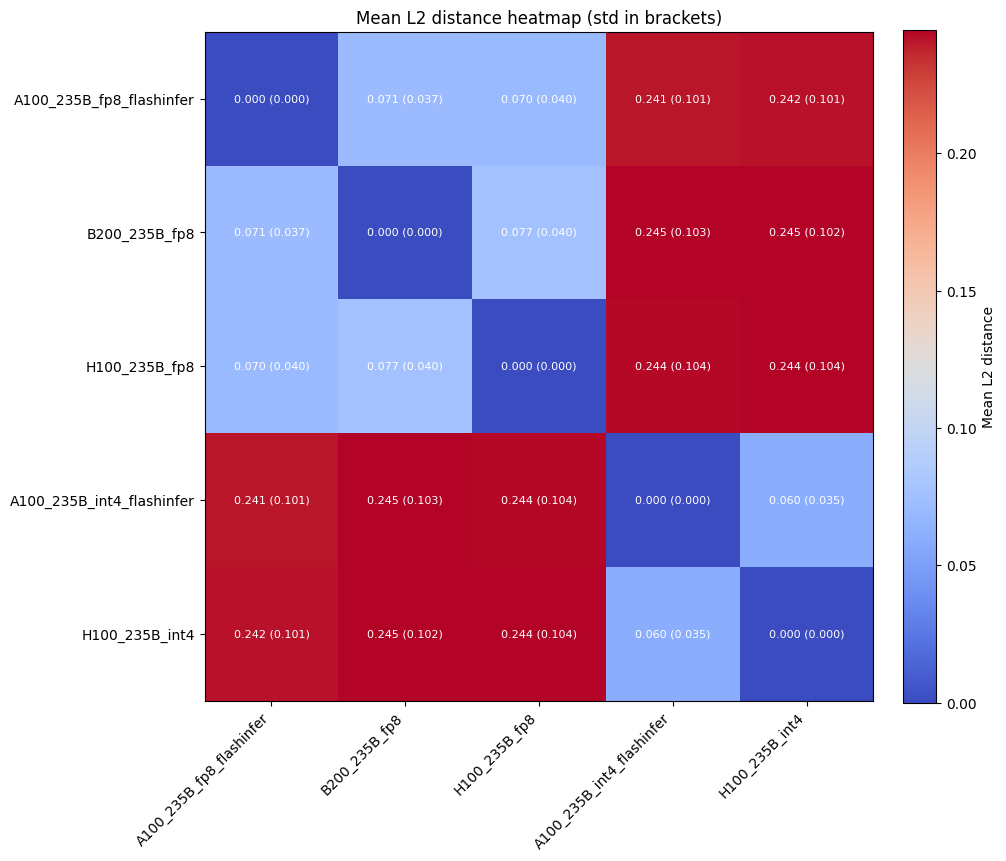

In [215]:
# Heatmap of mean pairwise distances (std in brackets)
# Rows/cols are runs; int4 runs are placed last.

def _is_int4(label: str) -> bool:
    s = label.lower()
    if "int4" in s:
        return True
    # fallback: check underlying path if present
    run_dir = data.get(label, {}).get("run_dir", "")
    return "int4" in str(run_dir).lower()

ordered = sorted(servers, key=lambda s: (_is_int4(s), s))

n = len(ordered)
mean_mat = np.zeros((n, n), dtype=float)
std_mat = np.zeros((n, n), dtype=float)

for i, a in enumerate(ordered):
    for j, b in enumerate(ordered):
        if i == j:
            mean_mat[i, j] = 0.0
            std_mat[i, j] = 0.0
            continue
        key = (a, b) if (a, b) in pairwise_dists else (b, a)
        dists = pairwise_dists[key]
        mean_mat[i, j] = float(np.mean(dists))
        std_mat[i, j] = float(np.std(dists))

fig, ax = plt.subplots(figsize=(1.6 * n + 2, 1.4 * n + 2))
im = ax.imshow(mean_mat, cmap="coolwarm")

ax.set_xticks(range(n))
ax.set_yticks(range(n))
ax.set_xticklabels(ordered, rotation=45, ha="right")
ax.set_yticklabels(ordered)
ax.set_title("Mean L2 distance heatmap (std in brackets)")

# annotate each cell with mean (std) using 3 digits
for i in range(n):
    for j in range(n):
        txt = f"{mean_mat[i, j]:.3f} ({std_mat[i, j]:.3f})"
        ax.text(j, i, txt, ha="center", va="center", fontsize=8, color="white")

cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label("Mean L2 distance")

plt.tight_layout()
plt.show()


## Transition to simulations

Everything above this point uses **measured distances** from real runs.

The following section switches to **statistical simulation**, modeling mismatches as Bernoulli/Binomial draws to build intuition about expected false positives and cheater detection power.

In [216]:
# (intentionally left blank; simulations start below)


## Cheater simulation

We treat each participant-to-participant validation as a **binomial** process: out of \(N\) queried nonces, each nonce mismatch is a “success” with expected probability \(p_0 = 0.02\) (set by the honest 98th-percentile distance threshold). Below we simulate samples with \(N=200\) and varying mismatch counts.

## Simulation primitives (parameters + helper)

Defines the simulation knobs:

- `N`: number of queried vectors/nonces per participant (e.g. 200)
- `P0`: expected honest mismatch rate (2%) induced by the 98th-percentile distance threshold
- `MAX_MISMATCHES`: upper bound for the fixed-count sweep

Also defines `make_mismatch_sample(...)`, which builds a boolean array with **exactly** `mismatches` `True` values and randomizes their positions.

In [219]:
import numpy as np
from scipy.stats import binomtest

# Simulation parameters
N = 200
P0 = 1 - percentile / 100
MAX_MISMATCHES = 40

rng = np.random.default_rng(0)

def make_mismatch_sample(n: int, mismatches: int, rng: np.random.Generator) -> np.ndarray:
    """Boolean array of length n with exactly `mismatches` True values."""
    if mismatches < 0 or mismatches > n:
        raise ValueError("mismatches must be in [0, n]")
    x = np.zeros(n, dtype=bool)
    x[:mismatches] = True
    rng.shuffle(x)
    return x


In [220]:
# Generate simulated samples for mismatch counts 0..20
samples = {
    m: make_mismatch_sample(N, m, rng)
    for m in range(MAX_MISMATCHES + 1)
}


## Binomial test table (mismatch-count sweep)

We treat the mismatch indicator vector as a **binomial sample**:

- \(N\) trials (queried nonces)
- \(k\) mismatches (out-of-threshold distances)
- Honest null hypothesis: \(X \sim \text{Binomial}(N, p_0)\) with \(p_0=2\%\)

We report two different probabilities:

- **p_value**: one-sided binomial test p-value \(P(X \ge k \mid p_0)\) (only detects *higher-than-expected* mismatch rates)
- **P(X=k | p0)**: exact probability of seeing *exactly* \(k\) mismatches under the honest null

In [221]:
from scipy.stats import binom

# Binomial test for each sample: H0 p = 0.02
# One-sided: detect only if observed mismatch rate is higher than expected
print(f"Binomial test (one-sided, greater) vs p0={P0:.2%} with N={N}")

header = f"{'mismatches':>10}  {'observed_rate':>13}  {'p_value':>12}  {'P(X=k | p0)':>12}"
print(header)

for m in range(MAX_MISMATCHES + 1):
    x = samples[m]
    k = int(x.sum())
    rate = k / N
    p_value = binomtest(k, N, p=P0, alternative="greater").pvalue
    p_exact = binom.pmf(k, N, P0)
    print(f"{m:10d}  {rate:13.3%}  {p_value:12.4g}  {p_exact:12.4g}")


Binomial test (one-sided, greater) vs p0=2.00% with N=200
mismatches  observed_rate       p_value   P(X=k | p0)
         0         0.000%             1       0.01759
         1         0.500%        0.9824       0.07179
         2         1.000%        0.9106        0.1458
         3         1.500%        0.7649        0.1963
         4         2.000%        0.5685        0.1973
         5         2.500%        0.3712        0.1579
         6         3.000%        0.2133        0.1047
         7         3.500%        0.1086       0.05923
         8         4.000%       0.04934       0.02916
         9         4.500%       0.02017        0.0127
        10         5.000%      0.007479      0.004949
        11         5.500%      0.002531      0.001744
        12         6.000%     0.0007862     0.0005607
        13         6.500%     0.0002255     0.0001655
        14         7.000%     5.997e-05     4.511e-05
        15         7.500%     1.486e-05     1.142e-05
        16         8.000

## Monte Carlo setup: generate random cheater samples

We generate \(M\) independent boolean arrays of length \(N\):

- Each entry is `True` (= mismatch) with probability `P_CHEAT`.
- This models the **realized mismatch outcomes** a verifier would see if the true mismatch rate were higher than honest (e.g. 4% instead of 2%).

These samples are then fed into the binomial test in the next cell.

In [222]:
# Cheater-rate Monte Carlo: generate M samples with true mismatch rate p_cheat
M = 1000
P_CHEAT = P0 * 2
ALPHA = 0.05
N = 200
cheat_samples = rng.random((M, N)) < P_CHEAT  # shape: (M, N), dtype: bool


## Monte Carlo power check (how often cheaters get flagged)

Here we repeatedly simulate a participant validation outcome (a boolean vector of mismatches) under a **cheater mismatch rate** (e.g. 4%), then apply the **one-sided** binomial test against the honest baseline \(p_0=2\%\).

- **Output**: one row per simulated sample with its mismatch count, observed rate, and p-value.
- **Summary**: how many of the \(M\) samples are flagged with p-value below `ALPHA` (an empirical detection rate / power estimate).

In [223]:
# Run one-sided binomial tests vs p0=2% and report detection rate
pvals = []

header = f"{'sample':>8}  {'mismatches':>10}  {'observed_rate':>13}  {'p_value':>12}"
print(f"Monte Carlo with M={M}, N={N}, true_p={P_CHEAT:.2%} (test H0: p={P0:.2%}, alternative='greater')")
print(header)

for i in range(M):
    k = int(cheat_samples[i].sum())
    rate = k / N
    p_value = binomtest(k, N, p=P0, alternative="greater").pvalue
    pvals.append(p_value)
    print(f"{i:8d}  {k:10d}  {rate:13.3%}  {p_value:12.4g}")

pvals = np.array(pvals)
flagged = int((pvals < ALPHA).sum())
print()
print(f"p_value < {ALPHA:.2g}: {flagged}/{M} = {flagged/M:.1%}")


Monte Carlo with M=1000, N=200, true_p=4.00% (test H0: p=2.00%, alternative='greater')
  sample  mismatches  observed_rate       p_value
       0          13         6.500%     0.0002255
       1           3         1.500%        0.7649
       2          12         6.000%     0.0007862
       3           9         4.500%       0.02017
       4           5         2.500%        0.3712
       5           4         2.000%        0.5685
       6           7         3.500%        0.1086
       7           8         4.000%       0.04934
       8           5         2.500%        0.3712
       9           8         4.000%       0.04934
      10           4         2.000%        0.5685
      11          10         5.000%      0.007479
      12           6         3.000%        0.2133
      13           6         3.000%        0.2133
      14          12         6.000%     0.0007862
      15           5         2.500%        0.3712
      16           6         3.000%        0.2133
      17     

## Weighted voting simulation (vote-share range for honest vs dishonest targets)

Each validator checks a target participant using \(N\) queried nonces.

- A nonce is a **mismatch** if its distance exceeds the threshold.
- The validator observes a mismatch count \(k\) out of \(N\).
- It computes a **one-sided** p-value against the honest baseline \(p_0=2\%\): \(p = P(X \ge k \mid X \sim \text{Binomial}(N, p_0))\).

A validator then **votes “cheater”** if \(p < \alpha\).

Validators have different **weights** (stake / voting power). The target is marked as cheater if the **sum of weights** of “cheater” votes exceeds a **quorum** (typically 50% of total weight).

In the last cell we simulate voting rounds for two cases:

- **Honest target**: true mismatch rate \(p_{true}=2\%\)
- **Dishonest target**: true mismatch rate \(p_{true}=4\%\)

For each case we show the **range/quantiles** of the fraction of validators voting “cheater” (both unweighted and weight-weighted) and how often a **weighted majority** is reached.

In [237]:
import numpy as np
from scipy.stats import binom

try:
    import requests
except Exception:
    requests = None

# --- knobs ---
PARTICIPANTS_URL = "http://node1.gonka.ai:8000/v1/epochs/current/participants"  # from debug-debug.ipynb
P0 = 0.02              # honest baseline mismatch probability
N_VALIDATE = 200       # number of queried nonces per validator
ALPHA_VOTE = 0.05      # vote cheater if p_value < alpha
WEIGHT_QUORUM = 0.5    # majority of total weight
TRIALS = 100_000       # Monte Carlo rounds per scenario
BATCH = 2_000          # batch size to control memory
RNG_SEED = 0

# --- load weights (same parsing as debug-debug.ipynb) ---
if isinstance(globals().get("participant"), dict) and globals()["participant"]:
    participant = globals()["participant"]
else:
    if requests is None:
        raise RuntimeError(
            "No `participant` dict found and `requests` is unavailable. "
            "Run the first cell in debug-debug.ipynb to populate `participant`, or install `requests`."
        )
    res = requests.get(PARTICIPANTS_URL, timeout=20).json()
    participant = {
        x["index"]: x.get("weight", 0)
        for x in res["active_participants"]["participants"]
        if x.get("weight")
    }

if not participant:
    raise RuntimeError("No participant weights found.")

ids = list(participant.keys())
w = np.array([float(participant[i]) for i in ids], dtype=float)
M = len(w)

# Normalize so total weight = 1 (quorum is WEIGHT_QUORUM)
w_sum = float(w.sum())
w_norm = w / w_sum

print(f"Loaded M={M} participants")
print(f"Total raw weight: {w_sum:.6g}")
print(f"Top-10 normalized weights: {np.sort(w_norm)[-10:][::-1]}")
print()

# Voting is equivalent to a threshold on k because the one-sided p-value
# p_value = P(X >= k | Binomial(N_VALIDATE, P0)) is monotone decreasing in k.

def k_critical(alpha: float) -> int:
    """Smallest k such that p_value < alpha (one-sided, greater)."""
    for k in range(N_VALIDATE + 1):
        p = binom.sf(k - 1, N_VALIDATE, P0)  # P(X >= k)
        if p < alpha:
            return k
    return N_VALIDATE + 1  # never votes

K_CRIT = k_critical(ALPHA_VOTE)
print(f"Vote rule: vote cheater if k >= {K_CRIT} mismatches out of N={N_VALIDATE} (alpha={ALPHA_VOTE:g})")
print()

rng_local = globals().get("rng")
if not isinstance(rng_local, np.random.Generator):
    rng_local = np.random.default_rng(RNG_SEED)


def simulate_vote_shares(p_true: float):
    """Return (unweighted_share, weighted_share) arrays of length TRIALS."""
    unweighted = np.empty(TRIALS, dtype=float)
    weighted = np.empty(TRIALS, dtype=float)

    off = 0
    while off < TRIALS:
        bs = min(BATCH, TRIALS - off)
        # k_{t,i} ~ Binomial(N_VALIDATE, p_true)
        k = rng_local.binomial(N_VALIDATE, p_true, size=(bs, M))
        votes = k >= K_CRIT
        unweighted[off : off + bs] = votes.mean(axis=1)
        weighted[off : off + bs] = (votes * w_norm).sum(axis=1)
        off += bs

    return unweighted, weighted


def summarize(name: str, unweighted: np.ndarray, weighted: np.ndarray):
    qs = [0.0, 0.05, 0.5, 0.95, 1.0]
    uq = np.quantile(unweighted, qs)
    wq = np.quantile(weighted, qs)
    flagged = (weighted > WEIGHT_QUORUM).mean()

    print(name)
    print(f"{'metric':>12}  {'min':>8}  {'p05':>8}  {'p50':>8}  {'p95':>8}  {'max':>8}")
    print(f"{'#votes/M':>12}  {uq[0]:8.3%}  {uq[1]:8.3%}  {uq[2]:8.3%}  {uq[3]:8.3%}  {uq[4]:8.3%}")
    print(f"{'weight_share':>12}  {wq[0]:8.3%}  {wq[1]:8.3%}  {wq[2]:8.3%}  {wq[3]:8.3%}  {wq[4]:8.3%}")
    print(f"P(weight_share > {WEIGHT_QUORUM:.0%}) = {flagged:.6g}")
    print()

# Run two scenarios: honest (2%) and dishonest (4%)
for p_true in [0.02, 0.04]:
    uw, ww = simulate_vote_shares(p_true)
    summarize(f"Scenario: true mismatch rate p_true={p_true:.2%}", uw, ww)



Loaded M=377 participants
Total raw weight: 5.65124e+06
Top-10 normalized weights: [0.10235005 0.06167298 0.03261176 0.02311845 0.02228182 0.0206167
 0.02047461 0.01952137 0.01852477 0.01824484]

Vote rule: vote cheater if k >= 8 mismatches out of N=200 (alpha=0.05)

Scenario: true mismatch rate p_true=2.00%
      metric       min       p05       p50       p95       max
    #votes/M    0.796%    3.183%    4.775%    6.897%   10.080%
weight_share    0.145%    1.404%    4.130%   12.335%   26.426%
P(weight_share > 50%) = 0

Scenario: true mismatch rate p_true=4.00%
      metric       min       p05       p50       p95       max
    #votes/M   43.501%   50.663%   54.907%   59.151%   66.048%
weight_share   27.828%   42.428%   55.112%   67.051%   80.315%
P(weight_share > 50%) = 0.73563



In [ ]:
# (intentionally left blank)
